In [6]:
import math
import random

In [25]:
class Value:

    def __init__ (self,data,_children = (), _op = '', label = ''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data = {self.data})"

    def __add__(self,other):
        other = other if isinstance (other, Value) else Value(other)
        out = Value(self.data + other.data , (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __radd__ (self,other):
        return self + other

    def __mul__ (self,other):
        other = other if isinstance (other, Value) else Value(other)
        out = Value(self.data * other.data , (self,other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __rmul__(self,other):
        return self * other

    def __neg__ (self):
        return self * -1

    def __sub__(self,other):
        other = other if isinstance (other, Value) else Value(other)
        return self + (-other)

    def __pow__(self,power):
        out = Value(self.data ** power, (self,), f'**{power}')

        def _backward():
            self.grad += power * (self.data ** (power -1)) * out.grad
        out._backward = _backward

        return out


    def sigmoid(self):
        x = self.data
        s = 1/(1 + math.exp(-x))
        out  = Value(s, (self, ), 'sigmoid')

        def _backward():
            self.grad += (s * (1-s)) * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(self.data if self.data > 0 else 0, (self, ), 'relu')

        def _backward():
            self.grad += (1.0 if self.data > 0 else 0.0) * out.grad
        out._backward = _backward

        return out
        
    

    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
           if v not in visited:
             visited.add(v)
             for child in v._prev:
                 build_topo(child)
             topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
          node._backward()

In [26]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot 

In [27]:
class Neuron:

    def __init__ (self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range (nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__ (self,x, activation = "relu"):

        act = sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
        if activation == "relu":
            return act.relu()
        elif activation == "sigmoid":
            return act.sigmoid()
        elif activation == "tanh":
            return act.tanh()
        else:
            return act
        
    def parameters (self):
        return self.w + [self.b]

class Layer:

    def __init__(self,nin,nout):
        self.neuron = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x, activation = "relu"):
        outs = [n(x) for n in self.neuron]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neuron for p in neuron.parameters()]

class MLP:

    def __init__ (self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer (sz[i], sz[i+1]) for i in range (len(nouts))]

    def __call__(self,x, activation = "relu"):
        for layers in self.layers:
            x = layers(x)
        return x

    def parameters(self):
        return[p for layer in self.layers for p in layer.parameters()]

In [28]:
# Creating a random dataset
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0]

n = MLP(3, [4,4,1])

In [29]:
for k in range (10):

    ypred = [n([Value(xi) for xi in x]) for x in xs]
    loss = 0
    for xi, yi in zip(xs, ys):
        xi = [Value(xij) for xij in xi]
        yi = Value(yi)

        pred = n(xi)
        loss += (pred - yi)**2

    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    for p in n.parameters():
        p.data += -0.05 * p.grad 

    print(k, loss)

0 Value(data = 4.0)
1 Value(data = 4.0)
2 Value(data = 4.0)
3 Value(data = 4.0)
4 Value(data = 4.0)
5 Value(data = 4.0)
6 Value(data = 4.0)
7 Value(data = 4.0)
8 Value(data = 4.0)
9 Value(data = 4.0)


In [30]:
ypred


[Value(data = 0), Value(data = 0), Value(data = 0), Value(data = 0)]

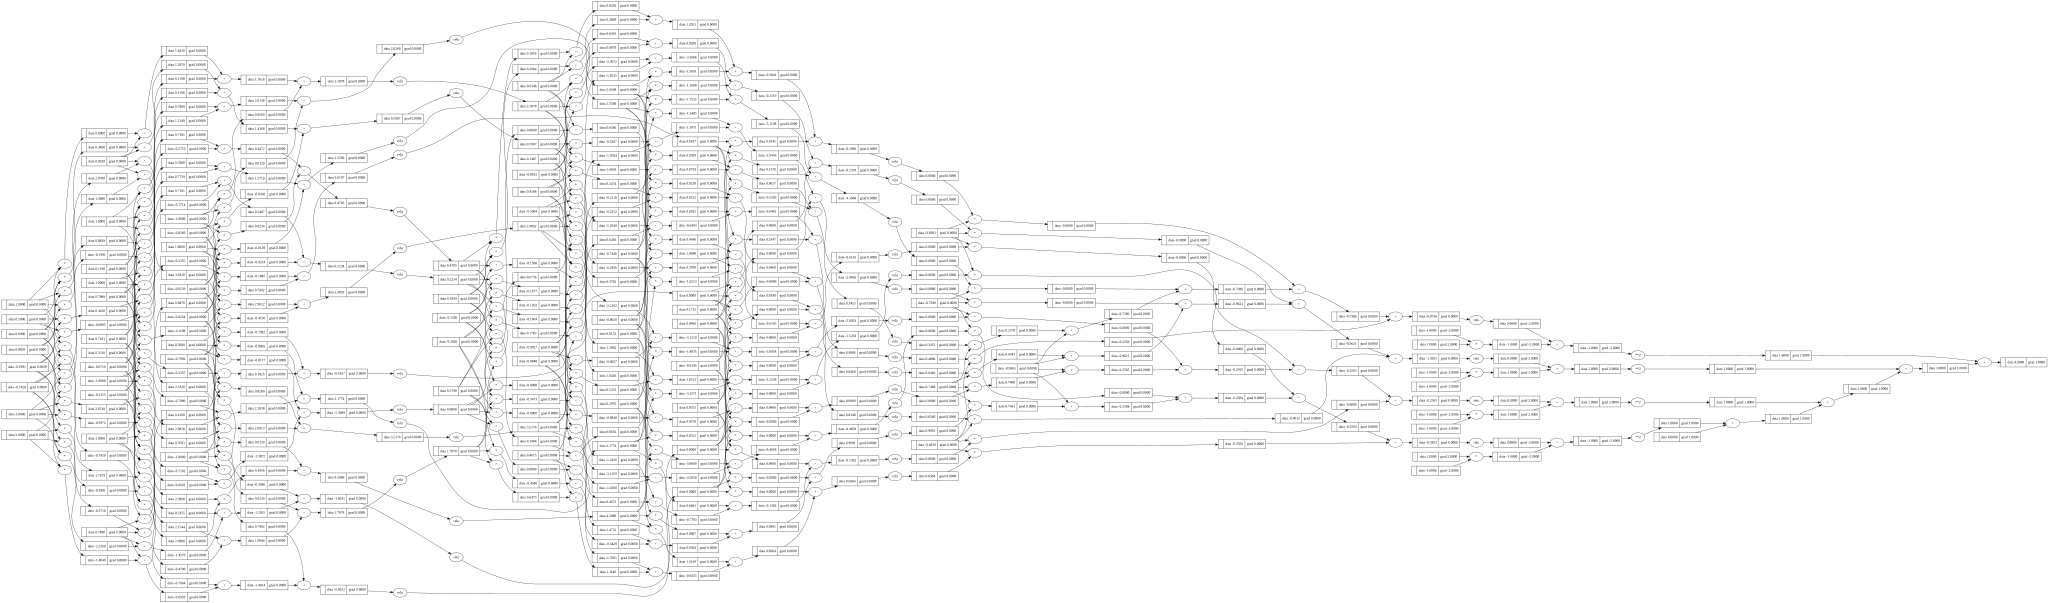

In [31]:
draw_dot(loss)
